In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import joblib

## 1. Import dữ liệu đã được xử lý

In [2]:
df = pd.read_csv('data/transformed_dataset.xls')
df.columns = [c.strip() for c in df.columns]

print(f"Dataset shape: {df.shape}")
print(f"Số lượng bệnh (Disease): {df['Disease'].nunique()}")
df.head()

Dataset shape: (4920, 134)
Số lượng bệnh (Disease): 41


,Unnamed: 0,Disease,Disease_code,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,...,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin,itching
0,0,Fungal infection,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,Fungal infection,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,Fungal infection,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,3,Fungal infection,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,4,Fungal infection,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


## 2. Tách features (X) và label (y)

In [3]:
# Loại bỏ các cột không phải triệu chứng
symptom_cols = [col for col in df.columns if col not in ['Unnamed: 0', 'Disease', 'Disease_code']]
X = df[symptom_cols]
y = df['Disease']

print(f"Số lượng triệu chứng (features): {len(symptom_cols)}")
print(f"Danh sách triệu chứng: {symptom_cols[:10]}...")

Số lượng triệu chứng (features): 131
Danh sách triệu chứng: ['abdominal_pain', 'abnormal_menstruation', 'acidity', 'acute_liver_failure', 'altered_sensorium', 'anxiety', 'back_pain', 'belly_pain', 'blackheads', 'bladder_discomfort']...


## 3. Chia dữ liệu: 80% Train - 20% Test

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tập Train: {X_train.shape[0]} mẫu")
print(f"Tập Test : {X_test.shape[0]} mẫu")

Tập Train: 3936 mẫu
Tập Test : 984 mẫu


## 4. Tìm K tối ưu bằng cách thử nhiều giá trị K

In [5]:
k_range = range(1, 26)  # Thử K từ 1 đến 25
accuracy_list = []
precision_list = []
recall_list = []

print("--- Đang thử nghiệm các giá trị K ---")
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)

    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)

    print(f"  K={k:2d}  |  Accuracy: {acc*100:.2f}%  |  Precision: {prec*100:.2f}%  |  Recall: {rec*100:.2f}%")

--- Đang thử nghiệm các giá trị K ---
  K= 1  |  Accuracy: 100.00%  |  Precision: 100.00%  |  Recall: 100.00%
  K= 2  |  Accuracy: 100.00%  |  Precision: 100.00%  |  Recall: 100.00%
  K= 3  |  Accuracy: 100.00%  |  Precision: 100.00%  |  Recall: 100.00%
  K= 4  |  Accuracy: 100.00%  |  Precision: 100.00%  |  Recall: 100.00%
  K= 5  |  Accuracy: 100.00%  |  Precision: 100.00%  |  Recall: 100.00%
  K= 6  |  Accuracy: 100.00%  |  Precision: 100.00%  |  Recall: 100.00%
  K= 7  |  Accuracy: 100.00%  |  Precision: 100.00%  |  Recall: 100.00%
  K= 8  |  Accuracy: 100.00%  |  Precision: 100.00%  |  Recall: 100.00%
  K= 9  |  Accuracy: 100.00%  |  Precision: 100.00%  |  Recall: 100.00%
  K=10  |  Accuracy: 100.00%  |  Precision: 100.00%  |  Recall: 100.00%
  K=11  |  Accuracy: 100.00%  |  Precision: 100.00%  |  Recall: 100.00%
  K=12  |  Accuracy: 100.00%  |  Precision: 100.00%  |  Recall: 100.00%
  K=13  |  Accuracy: 100.00%  |  Precision: 100.00%  |  Recall: 100.00%
  K=14  |  Accuracy: 99.49

## 5. Chọn K tốt nhất (theo Accuracy)

In [6]:
best_k = list(k_range)[np.argmax(accuracy_list)]
best_acc = max(accuracy_list)
print(f">>> K tối ưu: {best_k} với Accuracy = {best_acc*100:.2f}%")

>>> K tối ưu: 1 với Accuracy = 100.00%


## 6. Huấn luyện model cuối cùng với K tối ưu

In [7]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)
y_pred_final = knn_model.predict(X_test)

print("========== KẾT QUẢ ĐÁNH GIÁ MODEL KNN ==========")
print(f"Accuracy : {accuracy_score(y_test, y_pred_final)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_final, average='weighted', zero_division=0)*100:.2f}%")
print(f"Recall   : {recall_score(y_test, y_pred_final, average='weighted', zero_division=0)*100:.2f}%")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_final, zero_division=0))

========== KẾT QUẢ ĐÁNH GIÁ MODEL KNN ==========
Accuracy : 100.00%
Precision: 100.00%
Recall   : 100.00%

--- Classification Report ---
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00  

## 7. Vẽ đồ thị Accuracy, Precision, Recall theo K

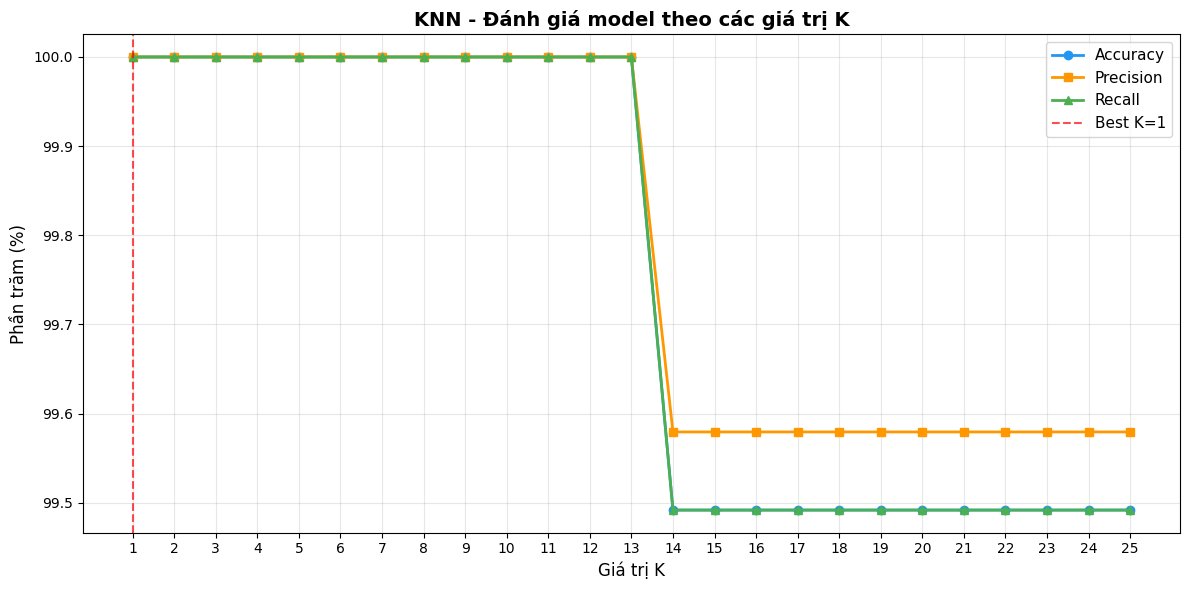

Đồ thị đã được lưu tại: model/knn_evaluation_chart.png


In [8]:
plt.figure(figsize=(12, 6))
plt.plot(list(k_range), [a * 100 for a in accuracy_list], 'o-', label='Accuracy', color='#2196F3', linewidth=2)
plt.plot(list(k_range), [p * 100 for p in precision_list], 's-', label='Precision', color='#FF9800', linewidth=2)
plt.plot(list(k_range), [r * 100 for r in recall_list], '^-', label='Recall', color='#4CAF50', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k}')

plt.xlabel('Giá trị K', fontsize=12)
plt.ylabel('Phần trăm (%)', fontsize=12)
plt.title('KNN - Đánh giá model theo các giá trị K', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model/knn_evaluation_chart.png', dpi=150)
plt.show()
print("Đồ thị đã được lưu tại: model/knn_evaluation_chart.png")

## 8. Lưu model KNN

In [9]:
# Lưu model
model_filename = 'model/knn_health_model.pkl'
joblib.dump(knn_model, model_filename)
print(f"Mô hình KNN đã được lưu tại: {model_filename}")

# Lưu thêm danh sách triệu chứng để chatbot sử dụng sau này
symptom_data = {
    'symptom_columns': symptom_cols,
    'diseases': list(y.unique()),
    'best_k': best_k
}
joblib.dump(symptom_data, 'model/knn_symptom_data.pkl')
print("Dữ liệu triệu chứng đã được lưu tại: model/knn_symptom_data.pkl")

Mô hình KNN đã được lưu tại: model/knn_health_model.pkl
Dữ liệu triệu chứng đã được lưu tại: model/knn_symptom_data.pkl
